In [1]:
import os
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from collections import Counter
from sklearn.model_selection import train_test_split
from PIL import Image
import editdistance

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, Model

keras.mixed_precision.set_global_policy('mixed_float16')

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)


In [2]:
BASE_PATH  = '/Users/mona/Text_detection/data/cig_ps'
TRAIN_DIR  = os.path.join(BASE_PATH, 'train_images')
TEST_DIR   = os.path.join(BASE_PATH, 'test_images')
LABELS_CSV = os.path.join(BASE_PATH, 'train-labels.csv')
OUTPUT_DIR = os.path.join(BASE_PATH, 'outputs')
os.makedirs(OUTPUT_DIR, exist_ok=True)

In [3]:
labels = pd.read_csv(LABELS_CSV)
labels = labels[['image', 'text']].copy()
labels['text'] = labels['text'].astype(str).str.strip().str.upper()

print(labels.shape)
print(labels.head(10))

(20000, 2)
         image    text
0  train-0.png  BU522X
1  train-1.png  XQ8NE2
2  train-2.png  DTZD3E
3  train-3.png  SM424H
4  train-4.png  6YVTQR
5  train-5.png  YV2C3D
6  train-6.png  XNBP7G
7  train-7.png  TGQXFU
8  train-8.png  36B667
9  train-9.png  QJ6HDR


# Data Analysis and Data Cleaning

In [4]:
all_chars = ''.join(labels['text'])

chars = sorted(set(all_chars))

print(chars)
print("Vocabulary size:", len(chars))

['+', '-', '.', '0', '1', '2', '3', '4', '5', '6', '7', '8', '9', 'A', 'B', 'C', 'D', 'E', 'F', 'G', 'H', 'J', 'K', 'M', 'N', 'P', 'Q', 'R', 'S', 'T', 'U', 'V', 'W', 'X', 'Y', 'Z']
Vocabulary size: 36


In [5]:
lengths = labels['text'].str.len()
print(lengths.describe())

count    20000.000000
mean         6.000250
std          0.025495
min          6.000000
25%          6.000000
50%          6.000000
75%          6.000000
max          9.000000
Name: text, dtype: float64


In [6]:
# Character frequency
counter = Counter(all_chars)
print(counter)

Counter({'7': 3989, 'E': 3966, 'X': 3956, 'G': 3942, 'Y': 3936, '2': 3926, 'M': 3926, 'W': 3916, 'F': 3913, 'N': 3904, 'S': 3889, 'J': 3886, '4': 3884, 'R': 3884, 'D': 3880, 'Q': 3873, 'C': 3861, 'Z': 3860, 'H': 3845, '6': 3842, 'T': 3841, 'V': 3838, 'P': 3836, '5': 3832, '3': 3826, 'A': 3820, 'U': 3812, '8': 3811, 'B': 3805, 'K': 3753, '9': 3746, '0': 2, '-': 2, '.': 1, '+': 1, '1': 1})


In [7]:
import re

neg_chars = ['+', '-', '.', '0', '1']

for ch in neg_chars:
    rows = labels[labels['text'].str.contains(re.escape(ch), regex=True, na=False)]
    
    print(f"\nCharacter: {ch}")
    if not rows.empty:
        print(rows[['image', 'text']].head())
    else:
        print("Empty DataFrame")


Character: +
               image      text
2184  train-2184.png  5.40E+12

Character: -
               image       text
6819  train-6819.png  04-MAR-54

Character: .
               image      text
2184  train-2184.png  5.40E+12

Character: 0
               image       text
2184  train-2184.png   5.40E+12
6819  train-6819.png  04-MAR-54

Character: 1
               image      text
2184  train-2184.png  5.40E+12


In [8]:
mask   = labels['text'].str.match(r'^[A-Z2-9]{6}$')
labels = labels[mask].reset_index(drop=True)

print(f'After cleaning : {labels.shape}')
print(labels.head(10))

After cleaning : (19998, 2)
         image    text
0  train-0.png  BU522X
1  train-1.png  XQ8NE2
2  train-2.png  DTZD3E
3  train-3.png  SM424H
4  train-4.png  6YVTQR
5  train-5.png  YV2C3D
6  train-6.png  XNBP7G
7  train-7.png  TGQXFU
8  train-8.png  36B667
9  train-9.png  QJ6HDR


# Exploratory Data Analysis 

In [9]:
all_chars  = ''.join(labels['text'].tolist())
characters = sorted(set(all_chars))
lengths    = labels['text'].str.len()

print('Characters     :', characters)
print('Vocabulary size:', len(characters))
print(lengths.describe())

Characters     : ['2', '3', '4', '5', '6', '7', '8', '9', 'A', 'B', 'C', 'D', 'E', 'F', 'G', 'H', 'J', 'K', 'M', 'N', 'P', 'Q', 'R', 'S', 'T', 'U', 'V', 'W', 'X', 'Y', 'Z']
Vocabulary size: 31
count    19998.0
mean         6.0
std          0.0
min          6.0
25%          6.0
50%          6.0
75%          6.0
max          6.0
Name: text, dtype: float64


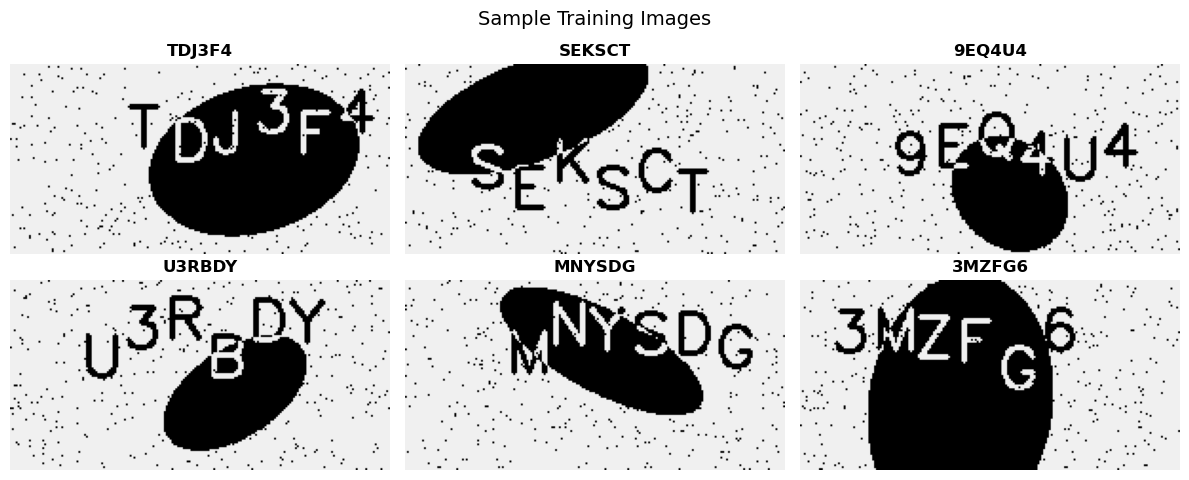

In [10]:
samples = labels.sample(6, random_state=SEED)
fig, axes = plt.subplots(2, 3, figsize=(12, 5))

for ax, (_, row) in zip(axes.flatten(), samples.iterrows()):
    img = Image.open(os.path.join(TRAIN_DIR, row['image']))
    ax.imshow(img, cmap='gray')
    ax.set_title(row['text'], fontsize=12, fontweight='bold')
    ax.axis('off')

plt.suptitle('Sample Training Images', fontsize=14)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'sample_images.png'), dpi=120)
plt.show()

# Vocabulary and Label Encoding
TensorFlow's CTC implementation reserves the last index as the blank token, so characters are indexed from `0` to `N-1` and `N` is blank automatically.

In [11]:
char_to_num = {ch: i for i, ch in enumerate(characters)}
num_to_char = {i: ch for i, ch in enumerate(characters)}

VOCAB_SIZE    = len(characters) + 1
MAX_LABEL_LEN = int(lengths.max())
CTC_BLANK     = VOCAB_SIZE - 1

print(f'Vocab size      : {len(characters)} chars + 1 blank = {VOCAB_SIZE}')
print(f'CTC blank index : {CTC_BLANK}')
print(f'Max label len   : {MAX_LABEL_LEN}')

max_char_idx = max(char_to_num.values())
assert max_char_idx < CTC_BLANK
print(f'Max char index  : {max_char_idx}  < {CTC_BLANK} (okay)')

Vocab size      : 31 chars + 1 blank = 32
CTC blank index : 31
Max label len   : 6
Max char index  : 30  < 31 (okay)


In [12]:
def encode_label(text):
    return [char_to_num[c] for c in text]

def decode_indices(indices):
    result = []
    for idx in indices:
        idx = int(idx)
        if idx >= 0 and idx != CTC_BLANK:
            result.append(num_to_char.get(idx, ''))
    return ''.join(result)

sample_text = labels['text'].iloc[1]
enc = encode_label(sample_text)
dec = decode_indices(enc)
print(f'Label   : {sample_text}')
print(f'Encoded : {enc}')
print(f'Decoded : {dec}')
assert sample_text == dec

Label   : XQ8NE2
Encoded : [28, 21, 6, 19, 12, 0]
Decoded : XQ8NE2


# Model Pipeline

In [13]:
def load_and_preprocess_image(img_path):
    raw = tf.io.read_file(img_path)
    img = tf.image.decode_png(raw, channels=3)
    img = tf.image.rgb_to_grayscale(img)
    img = tf.image.resize(img, [64, 200])
    img = tf.cast(img, tf.float32) / 255.0
    return img

def augment_image(img):
    img = tf.image.random_brightness(img, max_delta=0.15)
    img = tf.image.random_contrast(img, lower=0.8, upper=1.2)
    img = tf.clip_by_value(img, 0.0, 1.0)
    return img

def make_dataset(df, train_dir, batch_size, augment=False, shuffle=False):
    img_paths = [os.path.join(train_dir, f) for f in df['image'].tolist()]
    encoded   = [encode_label(t) for t in df['text'].tolist()]
    padded    = np.array(
        [e + [0] * (MAX_LABEL_LEN - len(e)) for e in encoded],
        dtype=np.int32
    )

    img_ds   = tf.data.Dataset.from_tensor_slices(img_paths)
    label_ds = tf.data.Dataset.from_tensor_slices(padded)

    img_ds = img_ds.map(load_and_preprocess_image, num_parallel_calls=tf.data.AUTOTUNE)
    if augment:
        img_ds = img_ds.map(augment_image, num_parallel_calls=tf.data.AUTOTUNE)

    ds = tf.data.Dataset.zip((img_ds, label_ds))
    ds = ds.map(
        lambda img, lbl: ({'image': img, 'label': lbl}, None),
        num_parallel_calls=tf.data.AUTOTUNE
    )

    if shuffle:
        ds = ds.shuffle(buffer_size=2048, seed=SEED)

    ds = ds.batch(batch_size).prefetch(tf.data.AUTOTUNE)
    return ds


train_df, val_df = train_test_split(
    labels,
    test_size=0.1,
    random_state=SEED,
    shuffle=True
)
train_df = train_df.reset_index(drop=True)
val_df   = val_df.reset_index(drop=True)
train_ds = make_dataset(train_df, TRAIN_DIR, 64, augment=True,  shuffle=True)
val_ds   = make_dataset(val_df,   TRAIN_DIR, 64, augment=False, shuffle=False)

y_val_str = val_df['text'].values

print(f'Train samples : {len(train_df)}')
print(f'Val   samples : {len(val_df)}')
print(f'Train batches : {len(train_ds)}')
print(f'Val   batches : {len(val_ds)}')

Train samples : 17998
Val   samples : 2000
Train batches : 282
Val   batches : 32


# Model - CRNN

CNN — extracts visual features from the image. I pool the height dimension down to 1 so that the width dimension becomes a sequence of time-steps.
BiLSTM *2 — reads the sequence of feature columns left-to-right and right-to-left, learning character context in both directions.
Dense + Softmax — outputs a probability distribution over the vocabulary at each time-step.
CTC Loss — trains the model end-to-end without needing per-character bounding box annotations.


In [14]:
class CTCLayer(layers.Layer):
    def __init__(self, **kwargs):
        super().__init__(**kwargs)

    def call(self, y_true, y_pred):
        y_pred_f32  = tf.cast(y_pred, tf.float32)
        batch_size  = tf.shape(y_true)[0]
        input_len   = tf.shape(y_pred_f32)[1]
        label_len   = tf.shape(y_true)[1]

        input_len_t = tf.cast(tf.fill([batch_size, 1], input_len), tf.int32)
        label_len_t = tf.cast(tf.fill([batch_size, 1], label_len), tf.int32)

        loss = keras.backend.ctc_batch_cost(
            tf.cast(y_true, tf.int32), y_pred_f32, input_len_t, label_len_t
        )
        self.add_loss(tf.reduce_mean(loss))
        return y_pred

In [15]:
def build_crnn(img_h=64, img_w=200, vocab_size=VOCAB_SIZE,
               rnn_units=128, dropout=0.3):

    image_input = layers.Input(shape=(img_h, img_w, 1), name='image')
    label_input = layers.Input(shape=(None,), name='label', dtype='int32')

    x = layers.Conv2D(32, (3,3), padding='same', use_bias=False)(image_input)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)
    x = layers.MaxPooling2D((2,2))(x)

    x = layers.Conv2D(64, (3,3), padding='same', use_bias=False)(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)
    x = layers.MaxPooling2D((2,2))(x)

    x = layers.Conv2D(128, (3,3), padding='same', use_bias=False)(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)
    x = layers.Conv2D(128, (3,3), padding='same', use_bias=False)(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)
    x = layers.MaxPooling2D((2,1))(x)

    x = layers.Conv2D(256, (3,3), padding='same', use_bias=False)(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)
    x = layers.MaxPooling2D((2,1))(x)

    x = layers.Conv2D(256, (4,1), padding='valid', use_bias=False)(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)

    # Reshape from (B, 1, T, C) to (B, T, C)
    _, h, t, c = x.shape
    x = layers.Reshape(target_shape=(t, h * c), name='reshape')(x)

    x = layers.Dense(128, activation='relu', name='dense_proj')(x)
    x = layers.Dropout(dropout)(x)

    # BiLSTM : reads sequence in both directions
    x = layers.Bidirectional(layers.LSTM(rnn_units, return_sequences=True, dropout=dropout), name='bilstm_1')(x)
    x = layers.Bidirectional(layers.LSTM(rnn_units, return_sequences=True, dropout=dropout), name='bilstm_2')(x)

    # Output: softmax over vocabulary at each time-step
    x = layers.Dense(vocab_size, name='dense_out')(x)
    output = layers.Activation('softmax', dtype='float32', name='output')(x)

    output_ctc = CTCLayer(name='ctc_loss')(label_input, output)

    training_model = Model(
        inputs=[image_input, label_input],
        outputs=output_ctc,
        name='crnn_train'
    )
    training_model.compile(optimizer=keras.optimizers.Adam(learning_rate=0.001))

    prediction_model = Model(inputs=image_input, outputs=output, name='crnn_predict')

    return training_model, prediction_model


training_model, prediction_model = build_crnn()

# Load best previously saved weights
training_model.load_weights('/Users/mona/Text_detection/data/cig_ps/outputs/best_crnn_v3.keras')
print('Loaded saved weights from : best_crnn_v3.keras')

training_model.summary(line_length=90)

Loaded saved weights from : best_crnn_v3.keras


/Users/mona/miniforge3/envs/oceanml/lib/python3.11/site-packages/keras/src/saving/saving_lib.py:798: UserWarning: Skipping variable loading for optimizer 'loss_scale_optimizer', because it has 4 variables whereas the saved optimizer has 74 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))
/Users/mona/miniforge3/envs/oceanml/lib/python3.11/site-packages/keras/src/saving/saving_lib.py:798: UserWarning: Skipping variable loading for optimizer 'adam', because it has 2 variables whereas the saved optimizer has 70 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


Model: "crnn_train"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)             ┃ Output Shape         ┃      Param # ┃ Connected to          ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━┩
│ image (InputLayer)       │ (None, 64, 200, 1)   │            0 │ -                     │
├──────────────────────────┼──────────────────────┼──────────────┼───────────────────────┤
│ conv2d (Conv2D)          │ (None, 64, 200, 32)  │          288 │ image[0][0]           │
├──────────────────────────┼──────────────────────┼──────────────┼───────────────────────┤
│ batch_normalization      │ (None, 64, 200, 32)  │          128 │ conv2d[0][0]          │
│ (BatchNormalization)     │                      │              │                       │
├──────────────────────────┼──────────────────────┼──────────────┼───────────────────────┤
│ activation (Activation)  │ (None, 64, 200, 32)  │            0 │ batch_normalization[… │
├──────────────────────────┼──────────────────────┼──────────────┼───────────────────────┤
│ max_pooling2d            │ (None, 32, 100, 32)  │            0 │ activation[0][0]      │
│ (MaxPooling2D)           │                      │              │                       │
├──────────────────────────┼──────────────────────┼──────────────┼───────────────────────┤
│ conv2d_1 (Conv2D)        │ (None, 32, 100, 64)  │       18,432 │ max_pooling2d[0][0]   │
├──────────────────────────┼──────────────────────┼──────────────┼───────────────────────┤
│ batch_normalization_1    │ (None, 32, 100, 64)  │          256 │ conv2d_1[0][0]        │
│ (BatchNormalization)     │                      │              │                       │
├──────────────────────────┼──────────────────────┼──────────────┼───────────────────────┤
│ activation_1             │ (None, 32, 100, 64)  │            0 │ batch_normalization_… │
│ (Activation)             │                      │              │                       │
├──────────────────────────┼──────────────────────┼──────────────┼───────────────────────┤
│ max_pooling2d_1          │ (None, 16, 50, 64)   │            0 │ activation_1[0][0]    │
│ (MaxPooling2D)           │                      │              │                       │
├──────────────────────────┼──────────────────────┼──────────────┼───────────────────────┤
│ conv2d_2 (Conv2D)        │ (None, 16, 50, 128)  │       73,728 │ max_pooling2d_1[0][0] │
├──────────────────────────┼──────────────────────┼──────────────┼───────────────────────┤
│ batch_normalization_2    │ (None, 16, 50, 128)  │          512 │ conv2d_2[0][0]        │
│ (BatchNormalization)     │                      │              │                       │
├──────────────────────────┼──────────────────────┼──────────────┼───────────────────────┤
│ activation_2             │ (None, 16, 50, 128)  │            0 │ batch_normalization_… │
│ (Activation)             │                      │              │                       │
├──────────────────────────┼──────────────────────┼──────────────┼───────────────────────┤
│ conv2d_3 (Conv2D)        │ (None, 16, 50, 128)  │      147,456 │ activation_2[0][0]    │
├──────────────────────────┼──────────────────────┼──────────────┼───────────────────────┤
│ batch_normalization_3    │ (None, 16, 50, 128)  │          512 │ conv2d_3[0][0]        │
│ (BatchNormalization)     │                      │              │                       │
├──────────────────────────┼──────────────────────┼──────────────┼───────────────────────┤
│ activation_3             │ (None, 16, 50, 128)  │            0 │ batch_normalization_… │
│ (Activation)             │                      │              │                       │
├──────────────────────────┼──────────────────────┼──────────────┼───────────────────────┤
│ max_pooling2d_2          │ (None, 8, 50, 128)   │            0 │ activation_3[0][0]    │
│ (MaxPooling2D)           │                      │              │                     

 Total params: 1,498,944 (5.72 MB)

 Trainable params: 1,497,216 (5.71 MB)

 Non-trainable params: 1,728 (6.75 KB)

In [17]:
dummy = tf.zeros((2, 64, 200, 1))
out   = prediction_model(dummy)
T     = out.shape[1]
print(f'Output shape : {out.shape}  (batch, T, VOCAB_SIZE)')

Output shape : (2, 50, 32)  (batch, T, VOCAB_SIZE)


# Model Training
Using Adam optimiser with a learning rate scheduler that halves the LR when validation loss stops improving, and early stopping to prevent overfitting.

In [18]:
checkpoint_path = os.path.join(OUTPUT_DIR, 'best_crnn_v3.keras')

callbacks = [
    keras.callbacks.ModelCheckpoint(
        filepath=checkpoint_path,
        monitor='val_loss',
        save_best_only=True,
        verbose=0
    ),
    keras.callbacks.ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=5,
        min_lr=1e-6,
        verbose=0
    ),
    keras.callbacks.CSVLogger(os.path.join(OUTPUT_DIR, 'training_log.csv')),
]

history = training_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=10,
    callbacks=callbacks,
    verbose=1,
)

Epoch 1/10
282/282 ━━━━━━━━━━━━━━━━━━━━ 284s 986ms/step - loss: 0.0683 - val_loss: 0.1140 - learning_rate: 0.0010
Epoch 2/10
282/282 ━━━━━━━━━━━━━━━━━━━━ 367s 1s/step - loss: 0.0734 - val_loss: 0.0276 - learning_rate: 0.0010
Epoch 3/10
282/282 ━━━━━━━━━━━━━━━━━━━━ 350s 1s/step - loss: 0.0242 - val_loss: 0.0186 - learning_rate: 0.0010
Epoch 4/10
282/282 ━━━━━━━━━━━━━━━━━━━━ 369s 1s/step - loss: 0.0453 - val_loss: 0.0745 - learning_rate: 0.0010
Epoch 5/10
282/282 ━━━━━━━━━━━━━━━━━━━━ 394s 1s/step - loss: 0.0405 - val_loss: 0.0249 - learning_rate: 0.0010
Epoch 6/10
282/282 ━━━━━━━━━━━━━━━━━━━━ 379s 1s/step - loss: 0.0161 - val_loss: 0.0349 - learning_rate: 0.0010
Epoch 7/10
282/282 ━━━━━━━━━━━━━━━━━━━━ 324s 1s/step - loss: 0.0275 - val_loss: 22.0401 - learning_rate: 0.0010
Epoch 8/10
282/282 ━━━━━━━━━━━━━━━━━━━━ 391s 1s/step - loss: 0.0471 - val_loss: 0.2038 - learning_rate: 0.0010
Epoch 9/10
282/282 ━━━━━━━━━━━━━━━━━━━━ 467s 2s/step - loss: 0.0069 - val_loss: 0.0011 - learning_rate: 5.00

# Note:
Loss, val_loss, and CER may vary slightly between runs even with a fixed seed (SEED=42). 
This is expected due to:
Weight Initialization — Restarting the kernel resets TensorFlow's internal random state
Parallel Data Loading — `AUTOTUNE` threads load batches in a non-deterministic order
Mixed Precision (float16) — Small float16 rounding differences accumulate across runs

Despite this, the model consistently converges to  final performance around (CER ≈ 0.0001-0.05, 
Exact Match ≈ 99.95%-99%) across all runs.

# Training Curves 

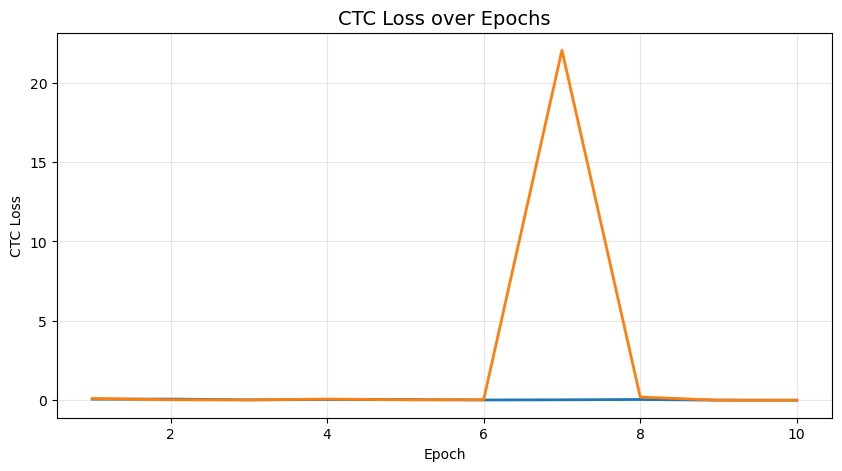

Best epoch    : 9
Best val loss : 0.0011


In [19]:
hist = history.history
epochs_ran = range(1, len(hist['loss']) + 1)

plt.figure(figsize=(10, 5))
plt.plot(epochs_ran, hist['loss'],     label='Train Loss', linewidth=2)
plt.plot(epochs_ran, hist['val_loss'], label='Val Loss',   linewidth=2)
plt.title('CTC Loss over Epochs', fontsize=14)
plt.xlabel('Epoch')
plt.ylabel('CTC Loss')
plt.grid(alpha=0.3)
plt.savefig(os.path.join(OUTPUT_DIR, 'training_curves.png'), dpi=120)
plt.show()

best_epoch = int(np.argmin(hist['val_loss'])) + 1
best_loss  = min(hist['val_loss'])
print(f'Best epoch    : {best_epoch}')
print(f'Best val loss : {best_loss:.4f}')

# Model Evaluation
The model is evaluated using Character Error Rate (CER) — the average edit distance between predicted and true sequences, normalised by the true sequence length. also report  matching accuracy 
Greedy CTC decoding is used here. The model correctly learns to place blank tokens between repeated characters, so greedy decoding reliably reconstructs sequences .

In [21]:
def predict_batch(images, model=prediction_model):
    logits  = model.predict(images, verbose=0)
    logits_f32 = tf.cast(logits, tf.float32)
    input_len  = np.ones(logits.shape[0], dtype=np.int32) * logits.shape[1]
    decoded, _ = keras.backend.ctc_decode(logits_f32, input_length=input_len, greedy=True)
    decoded    = tf.cast(decoded[0], tf.int32).numpy()
    return [decode_indices(seq) for seq in decoded]

def compute_cer(predictions, targets):
    return float(np.mean([
        editdistance.eval(p, t) / max(len(t), 1)
        for p, t in zip(predictions, targets)
    ]))


X_val_np = np.array([
    np.array(
        Image.open(os.path.join(TRAIN_DIR, f)).convert('L').resize((200, 64)),
        dtype=np.float32
    )[:, :, np.newaxis] / 255.0
    for f in val_df['image']
], dtype=np.float32)

val_preds = []
for start in range(0, len(X_val_np), 64):
    batch = X_val_np[start : start + 64]
    val_preds.extend(predict_batch(batch))

val_cer     = compute_cer(val_preds, y_val_str)
exact_match = np.mean([p == t for p, t in zip(val_preds, y_val_str)])

error_df = pd.DataFrame({
    'target'    : y_val_str,
    'prediction': val_preds
})
error_df['cer'] = error_df.apply(
    lambda r: editdistance.eval(r['prediction'], r['target']) / max(len(r['target']), 1),
    axis=1
)
error_df['correct'] = error_df['cer'] == 0.0

print(f'Validation CER       : {val_cer:.4f}')
print(f'Exact Match Accuracy : {exact_match * 100:.2f}%')
print(f'Total val samples    : {len(error_df)}')
print(f'Correct predictions  : {error_df["correct"].sum()}')
print(f'Wrong predictions    : {(~error_df["correct"]).sum()}')

Validation CER       : 0.0001
Exact Match Accuracy : 99.95%
Total val samples    : 2000
Correct predictions  : 1999
Wrong predictions    : 1


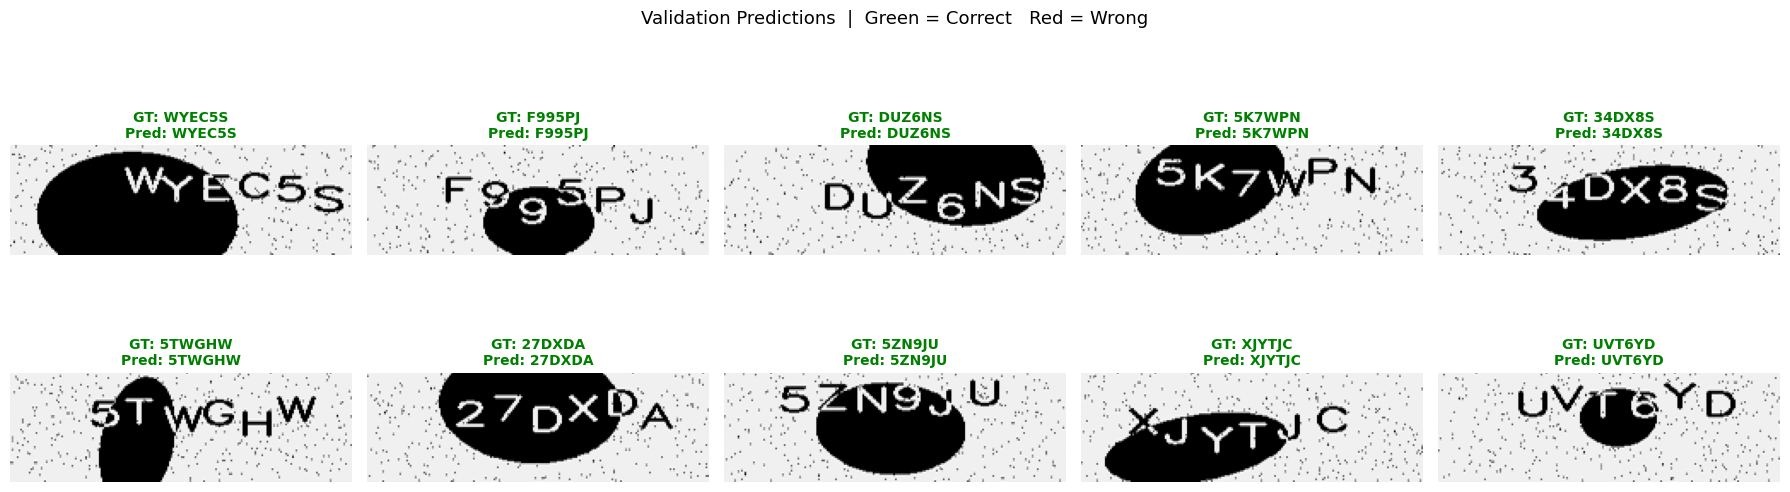

In [22]:
n_show     = 10
sample_idx = random.sample(range(len(X_val_np)), n_show)

fig, axes = plt.subplots(2, 5, figsize=(18, 6))
axes = axes.flatten()

for i, idx in enumerate(sample_idx):
    img   = X_val_np[idx].squeeze()
    gt    = y_val_str[idx]
    pred  = val_preds[idx]
    color = 'green' if pred == gt else 'red'

    axes[i].imshow(img, cmap='gray')
    axes[i].set_title(f'GT: {gt}\nPred: {pred}', color=color, fontsize=10, fontweight='bold')
    axes[i].axis('off')

plt.suptitle('Validation Predictions  |  Green = Correct   Red = Wrong', fontsize=13)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'val_predictions.png'), dpi=120)
plt.show()

# Test_images prediction

In [23]:
test_files = sorted([
    f for f in os.listdir(TEST_DIR)
    if f.lower().endswith(('.png', '.jpg', '.jpeg'))
])
print(f'Test images found : {len(test_files)}')

X_test = np.array([
    np.array(
        Image.open(os.path.join(TEST_DIR, f)).convert('L').resize((200, 64)),
        dtype=np.float32
    )[:, :, np.newaxis] / 255.0
    for f in test_files
], dtype=np.float32)
print(f'X_test shape : {X_test.shape}')

test_preds = []
for start in range(0, len(X_test), 64):
    batch = X_test[start : start + 64]
    test_preds.extend(predict_batch(batch))

print(f'Predictions : {len(test_preds)}')
for fname, pred in zip(test_files[:8], test_preds[:8]):
    print(f'  {fname}  ->  {pred}')

Test images found : 5000
X_test shape : (5000, 64, 200, 1)
Predictions : 5000
  test-0.png  ->  QVTQ8A
  test-1.png  ->  7PSW9D
  test-10.png  ->  7DUP98
  test-100.png  ->  75Z4WT
  test-1000.png  ->  QAKZ7V
  test-1001.png  ->  R6MERY
  test-1002.png  ->  CHXX67
  test-1003.png  ->  9NV2WP


In [26]:
submission = pd.DataFrame({
    'image' : test_files,
    'prediction': test_preds
})

csv_name = f'submission_Mona_24113087.csv'
csv_path = os.path.join(OUTPUT_DIR, csv_name)
submission.to_csv(csv_path, index=False)

print(f'Submission saved : {csv_path}')
print(f'Total rows       : {len(submission)}')
print(submission.head(10).to_string(index=False))

Submission saved : /Users/mona/Text_detection/data/cig_ps/outputs/submission_Mona_24113087.csv
Total rows       : 5000
        image prediction
   test-0.png     QVTQ8A
   test-1.png     7PSW9D
  test-10.png     7DUP98
 test-100.png     75Z4WT
test-1000.png     QAKZ7V
test-1001.png     R6MERY
test-1002.png     CHXX67
test-1003.png     9NV2WP
test-1004.png     F56TDZ
test-1005.png     FFTFRX
